# Notebook 03: Model Training

The models trained are: <br>
<br>
- Logistic Regression<br>
- Decision Tree<br>
- Random Forest<br>
- MLP Neural Network


### Cell 1

In [1]:
from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.exceptions import ConvergenceWarning

### Cell 2: Project paths and configs

In [30]:
def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results" / "03_model_training"
CONFIGS_DIR = PROJECT_ROOT / "configs"
LOGS_DIR = PROJECT_ROOT / "logs"
PLOTS_DIR = PROJECT_ROOT / "plots" / "03_model_training"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FORCE_RETRAIN = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Force retrain: {FORCE_RETRAIN}")

Project root: /home/iailab42/khans1/projects/xai
Force retrain: False


### Cell 3: Load Processed Data

In [16]:
def load_processed_data(data_dir: Path):
    required_files = {
        "X_train": data_dir / "X_train.csv",
        "X_test": data_dir / "X_test.csv",
        "X_train_scaled": data_dir / "X_train_scaled.csv",
        "X_test_scaled": data_dir / "X_test_scaled.csv",
        "y_train": data_dir / "y_train.csv",
        "y_test": data_dir / "y_test.csv",
    }

    missing_files = [
        str(path)
        for path in required_files.values()
        if not path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Missing files:\n" + "\n".join(missing_files)
        )

    X_train = pd.read_csv(required_files["X_train"])
    X_test = pd.read_csv(required_files["X_test"])
    X_train_scaled = pd.read_csv(required_files["X_train_scaled"])
    X_test_scaled = pd.read_csv(required_files["X_test_scaled"])

    y_train_full = pd.read_csv(required_files["y_train"])
    y_test_full = pd.read_csv(required_files["y_test"])

    return X_train, X_test, X_train_scaled, X_test_scaled, y_train_full, y_test_full


X_train, X_test, X_train_scaled, X_test_scaled, y_train_full, y_test_full = load_processed_data(DATA_PROCESSED_DIR)

print("Data loaded successfully.")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_train_full: {y_train_full.shape}")
print(f"y_test_full: {y_test_full.shape}")

Data loaded successfully.
X_train: (10834, 16)
X_test: (2709, 16)
X_train_scaled: (10834, 16)
X_test_scaled: (2709, 16)
y_train_full: (10834, 3)
y_test_full: (2709, 3)


### Cell 4: Load Label Mapping

In [6]:
label_mapping_path = DATA_PROCESSED_DIR / "label_mapping.json"

if label_mapping_path.exists():
    with open(label_mapping_path, "r", encoding="utf-8") as file:
        label_mapping = json.load(file)
else:
    label_mapping = {}

print("Label mapping:")
label_mapping

Label mapping:


{'BARBUNYA': 0,
 'BOMBAY': 1,
 'CALI': 2,
 'DERMASON': 3,
 'HOROZ': 4,
 'SEKER': 5,
 'SIRA': 6}

In [17]:
TARGET_COLUMN = "Class_encoded"

if TARGET_COLUMN not in y_train_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_train.csv")

if TARGET_COLUMN not in y_test_full.columns:
    raise ValueError(f"{TARGET_COLUMN} not found in y_test.csv")

y_train = y_train_full[TARGET_COLUMN].reset_index(drop=True)
y_test = y_test_full[TARGET_COLUMN].reset_index(drop=True)

train_sample_ids = y_train_full["sample_id"].reset_index(drop=True)
test_sample_ids = y_test_full["sample_id"].reset_index(drop=True)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Train labels: {sorted(y_train.unique())}")
print(f"Test labels: {sorted(y_test.unique())}")

y_train shape: (10834,)
y_test shape: (2709,)
Train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


### Cell 5: Define Models

In [18]:
model_config = {
    "logistic_regression": {
        "model_type": "LogisticRegression",
        "use_scaled_data": True,
        "params": {
            "max_iter": 1000,
            "random_state": RANDOM_STATE
        }
    },

    "decision_tree": {
        "model_type": "DecisionTreeClassifier",
        "use_scaled_data": False,
        "params": {
            "random_state": RANDOM_STATE
        }
    },

    "random_forest": {
        "model_type": "RandomForestClassifier",
        "use_scaled_data": False,
        "params": {
            "n_estimators": 200,
            "random_state": RANDOM_STATE,
            "n_jobs": -1
        }
    },

    "mlp": {
        "model_type": "MLPClassifier",
        "use_scaled_data": True,
        "params": {
            "hidden_layer_sizes": [64, 32],
            "activation": "relu",
            "solver": "adam",
            "alpha": 0.0001,
            "learning_rate_init": 0.001,
            "max_iter": 500,
            "early_stopping": True,
            "validation_fraction": 0.1,
            "n_iter_no_change": 20,
            "random_state": RANDOM_STATE
        }
    }
}


models = {
    "logistic_regression": LogisticRegression(
        **model_config["logistic_regression"]["params"]
    ),

    "decision_tree": DecisionTreeClassifier(
        **model_config["decision_tree"]["params"]
    ),

    "random_forest": RandomForestClassifier(
        **model_config["random_forest"]["params"]
    ),

    "mlp": MLPClassifier(
        hidden_layer_sizes=tuple(model_config["mlp"]["params"]["hidden_layer_sizes"]),
        activation=model_config["mlp"]["params"]["activation"],
        solver=model_config["mlp"]["params"]["solver"],
        alpha=model_config["mlp"]["params"]["alpha"],
        learning_rate_init=model_config["mlp"]["params"]["learning_rate_init"],
        max_iter=model_config["mlp"]["params"]["max_iter"],
        early_stopping=model_config["mlp"]["params"]["early_stopping"],
        validation_fraction=model_config["mlp"]["params"]["validation_fraction"],
        n_iter_no_change=model_config["mlp"]["params"]["n_iter_no_change"],
        random_state=model_config["mlp"]["params"]["random_state"]
    )
}


config_path = CONFIGS_DIR / "model_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(model_config, file, indent=4)

print(f"Model configuration saved to: {config_path}")
print("Models initialized successfully.")

Model configuration saved to: /home/iailab42/khans1/projects/xai/configs/model_config.json
Models initialized successfully.


### Cell 6: Train-or-Load Helper Function

In [19]:
def train_or_load_model(
    model_name: str,
    model,
    model_path: Path,
    X_train_data: pd.DataFrame,
    y_train_data: pd.Series,
    force_retrain: bool = False
):
    start_time = time.time()
    loaded_from_disk = False
    warning_messages = []

    if model_path.exists() and not force_retrain:
        print(f"Loading existing model: {model_name}")
        trained_model = joblib.load(model_path)
        training_time = 0.0
        loaded_from_disk = True

    else:
        print(f"Training model: {model_name}")

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", ConvergenceWarning)

            trained_model = model.fit(X_train_data, y_train_data)

            for warning in caught_warnings:
                warning_messages.append(str(warning.message))

        joblib.dump(trained_model, model_path)
        training_time = time.time() - start_time

        print(f"Saved model: {model_path}")

    summary = {
        "model_name": model_name,
        "model_path": str(model_path),
        "loaded_from_disk": loaded_from_disk,
        "training_time_seconds": round(training_time, 4),
        "warnings": warning_messages
    }

    return trained_model, summary

### Cell 7 — Train or Load All Models

In [20]:
trained_models = {}
training_summaries = []

for model_name, model in models.items():
    use_scaled_data = model_config[model_name]["use_scaled_data"]

    if use_scaled_data:
        X_train_used = X_train_scaled
    else:
        X_train_used = X_train

    model_path = MODELS_DIR / f"{model_name}.pkl"

    trained_model, summary = train_or_load_model(
        model_name=model_name,
        model=model,
        model_path=model_path,
        X_train_data=X_train_used,
        y_train_data=y_train,
        force_retrain=FORCE_RETRAIN
    )

    trained_models[model_name] = trained_model
    training_summaries.append(summary)

print("All models are ready.")

Training model: logistic_regression
Saved model: /home/iailab42/khans1/projects/xai/models/logistic_regression.pkl
Training model: decision_tree
Saved model: /home/iailab42/khans1/projects/xai/models/decision_tree.pkl
Training model: random_forest
Saved model: /home/iailab42/khans1/projects/xai/models/random_forest.pkl
Training model: mlp
Saved model: /home/iailab42/khans1/projects/xai/models/mlp.pkl
All models are ready.


### Cell 9: Save Predictions and Probabilities

In [21]:
def save_predictions_and_probabilities(
    model_name: str,
    model,
    X_test_data: pd.DataFrame,
    y_test_data: pd.Series,
    sample_ids: pd.Series,
    results_dir: Path
):
    start_time = time.time()

    y_pred = model.predict(X_test_data)

    prediction_time = time.time() - start_time

    predictions_df = pd.DataFrame({
        "sample_id": sample_ids,
        "true_label": y_test_data,
        "predicted_label": y_pred
    })

    predictions_path = results_dir / f"{model_name}_predictions.csv"
    predictions_df.to_csv(predictions_path, index=False)

    probabilities_path = None

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test_data)

        probabilities_df = pd.DataFrame(
            probabilities,
            columns=[f"class_{class_id}_probability" for class_id in model.classes_]
        )

        probabilities_df.insert(0, "sample_id", sample_ids)
        probabilities_df.insert(1, "true_label", y_test_data.values)
        probabilities_df.insert(2, "predicted_label", y_pred)

        probabilities_path = results_dir / f"{model_name}_probabilities.csv"
        probabilities_df.to_csv(probabilities_path, index=False)

    return {
        "model_name": model_name,
        "prediction_time_seconds": round(prediction_time, 4),
        "predictions_path": str(predictions_path),
        "probabilities_path": str(probabilities_path) if probabilities_path else None
    }


prediction_summaries = []

for model_name, model in trained_models.items():
    use_scaled_data = model_config[model_name]["use_scaled_data"]

    if use_scaled_data:
        X_test_used = X_test_scaled
    else:
        X_test_used = X_test

    prediction_summary = save_predictions_and_probabilities(
        model_name=model_name,
        model=model,
        X_test_data=X_test_used,
        y_test_data=y_test,
        sample_ids=test_sample_ids,
        results_dir=RESULTS_DIR
    )

    prediction_summaries.append(prediction_summary)

print("Predictions and probabilities saved.")

Predictions and probabilities saved.


In [23]:
training_summary = {
    "project_stage": "03_model_training",
    "random_state": RANDOM_STATE,
    "force_retrain": FORCE_RETRAIN,
    "target_column_used": TARGET_COLUMN,
    "models": list(trained_models.keys()),
    "training_summaries": training_summaries,
    "prediction_summaries": prediction_summaries,
    "data_shapes": {
        "X_train": list(X_train.shape),
        "X_test": list(X_test.shape),
        "X_train_scaled": list(X_train_scaled.shape),
        "X_test_scaled": list(X_test_scaled.shape),
        "y_train": list(y_train.shape),
        "y_test": list(y_test.shape)
    }
}

summary_json_path = RESULTS_DIR / "training_summary.json"

with open(summary_json_path, "w", encoding="utf-8") as file:
    json.dump(training_summary, file, indent=4)

print(f"Training summary saved to: {summary_json_path}")

Training summary saved to: /home/iailab42/khans1/projects/xai/results/03_model_training/training_summary.json


In [24]:
summary_rows = []

for train_summary, pred_summary in zip(training_summaries, prediction_summaries):
    summary_rows.append({
        "model_name": train_summary["model_name"],
        "loaded_from_disk": train_summary["loaded_from_disk"],
        "training_time_seconds": train_summary["training_time_seconds"],
        "prediction_time_seconds": pred_summary["prediction_time_seconds"],
        "warnings_count": len(train_summary["warnings"])
    })

summary_df = pd.DataFrame(summary_rows)

summary_csv_path = RESULTS_DIR / "model_training_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)

summary_df

,model_name,loaded_from_disk,training_time_seconds,prediction_time_seconds,warnings_count
0,logistic_regression,False,0.1445,0.0013,0
1,decision_tree,False,0.2083,0.0010,0
2,random_forest,False,0.5305,0.0453,0
3,mlp,False,1.2793,0.0021,0


In [26]:
for name, model in trained_models.items():
    
    print(f"\n{name}")

    if hasattr(model, "n_iter_"):
        print(f"Iterations/Epochs: {model.n_iter_}")

    if hasattr(model, "loss_"):
        print(f"Final Loss: {model.loss_:.6f}")


logistic_regression
Iterations/Epochs: [84]

decision_tree

random_forest

mlp
Iterations/Epochs: 52
Final Loss: 0.170031


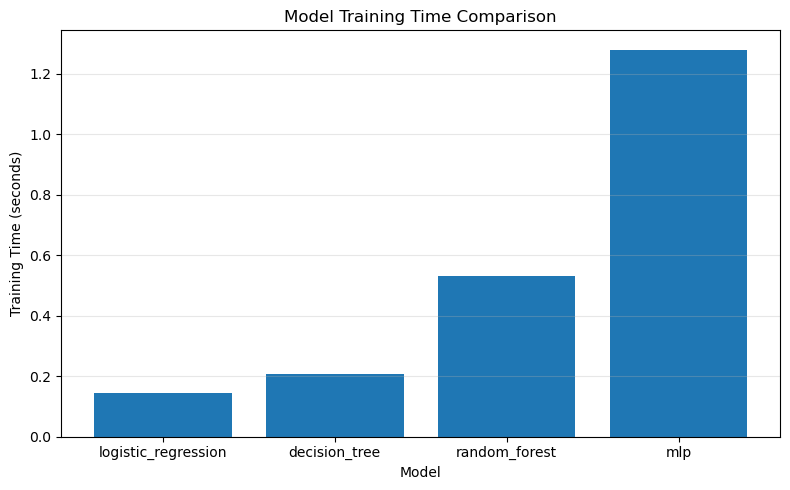

Saved: /home/iailab42/khans1/projects/xai/plots/03_model_training/training_time_comparison.png


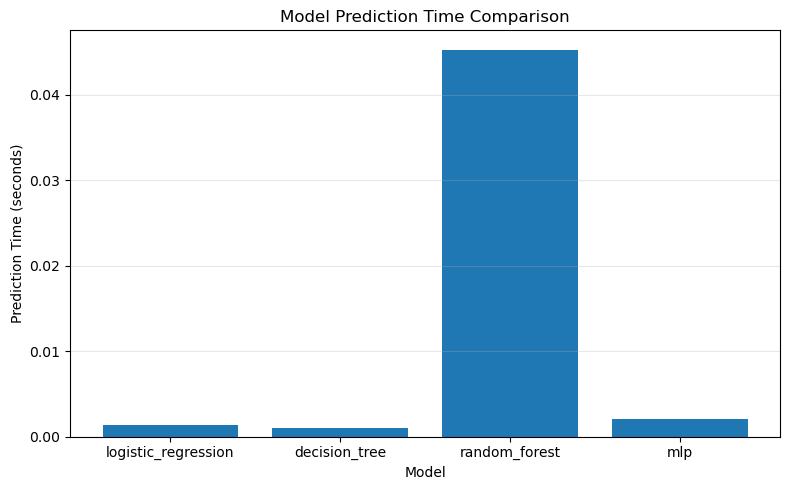

Saved: /home/iailab42/khans1/projects/xai/plots/03_model_training/prediction_time_comparison.png
Iterations Used: 52
Final Loss: 0.170031


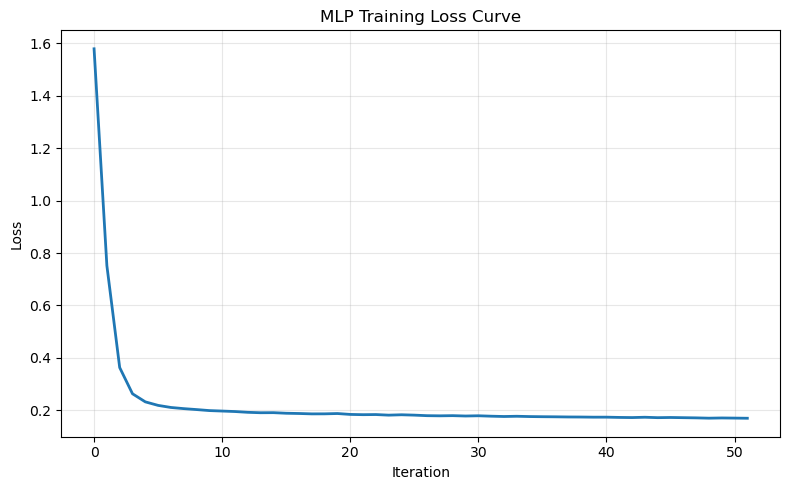

Saved: /home/iailab42/khans1/projects/xai/plots/03_model_training/mlp_loss_curve.png


In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["model_name"],
    summary_df["training_time_seconds"]
)

plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "training_time_comparison.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")

plt.figure(figsize=(8, 5))

plt.bar(
    summary_df["model_name"],
    summary_df["prediction_time_seconds"]
)

plt.title("Model Prediction Time Comparison")
plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "prediction_time_comparison.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")

mlp_model = trained_models["mlp"]

print(f"Iterations Used: {mlp_model.n_iter_}")
print(f"Final Loss: {mlp_model.loss_:.6f}")

plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_,
    linewidth=2
)

plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.3)

plt.tight_layout()

plot_path = PLOTS_DIR / "mlp_loss_curve.png"

plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {plot_path}")